# Libs

In [1]:
# load all libs
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import logging
import string
import pathlib
import itertools
import random
import ast
import re
from typing import List, Literal, Optional, Iterator, Tuple, Dict, Any, Callable, Union
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, precision_recall_curve
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed

In [2]:
# global configs
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)

# Function definitions

In [3]:
# f: filepath -> dataframe
def load_csv_to_dataframe(file_path: str) -> Optional[pd.DataFrame]:
    """
    Functional catch of csv reading errors
    """
    try:
        df = pd.read_csv(file_path)
        logging.info(f"{file_path} is data")
        return df
    except FileNotFoundError:
        logging.error(f"{file_path} not a valid path")
        return None
    except Exception as e:
        logging.error(f"unknown error: {e}")
        return None

In [4]:
# f: corpus -> pre_processed_corpus
def download_nltk_resources():
    """
    Download all required nltk list, function to catch errors
    """
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        logging.info("punkt...")
        nltk.download("punkt", quiet=True)
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        logging.info("stopwords...")
        nltk.download("stopwords", quiet=True)
    try:
        nltk.data.find("corpora/wordnet")
    except LookupError:
        logging.info("lemmatizer...")
        nltk.download("wordnet", quiet=True)
    try:
        nltk.data.find("corpora/omw-1.4")
    except LookupError:
        logging.info("omw...")
        nltk.download("omw-1.4", quiet=True)
    logging.info("nltk stuff done")


# cleaning functions objects instatiation
STOP_WORDS = None
STEMMER = None
LEMMATIZER = None
PUNCT_TABLE = None


def initialize_nlp_constants():
    """
    this is just to avoid defining stuff from nltk before
    using the nltk downloader
    """
    global STOP_WORDS, PUNCT_TABLE, STEMMER, LEMMATIZER

    logging.info("init nltk resources...")

    def _check_and_download(resource_id, resource_path):
        try:
            nltk.data.find(resource_path)
            logging.info(f"NLTK resource '{resource_id}' already present")
            nltk.download(resource_id, quiet=True)
            logging.info(f"NLTK resource '{resource_id}' downloaded")
        except LookupError:
            logging.info(f"dowloanding nltk resource: '{resource_id}'...")
            nltk.download(resource_id, quiet=True)
            logging.info(f"nltk resource '{resource_id}' downloaded")

    _check_and_download("punkt", "tokenizers/punkt")
    _check_and_download("punkt_tab", "tokenizers/punkt")
    _check_and_download("stopwords", "corpora/stopwords")
    _check_and_download("wordnet", "corpora/wordnet")
    _check_and_download("omw-1.4", "corpora/omw-1.4")

    STOP_WORDS = set(nltk.corpus.stopwords.words("english"))
    PUNCT_TABLE = str.maketrans("", "", string.punctuation)
    STEMMER = nltk.stem.PorterStemmer()
    LEMMATIZER = nltk.stem.WordNetLemmatizer()

    logging.info("nltk constant initialized")


initialize_nlp_constants()


def _clean_document(
    doc: str,
    to_lower: bool,
    remove_punct: bool,
    remove_stopwords: bool,
    normalization_strategy: Literal["none", "stem", "lemmatize"],
) -> str:
    """
    Applies the chosen cleaning strategy to a document
    """

    # lowercasing
    if to_lower:
        doc = doc.lower()

    # punctuation removal
    if remove_punct:
        doc = doc.translate(PUNCT_TABLE)

    # tokenization
    if remove_stopwords or normalization_strategy != "none":
        tokens = nltk.word_tokenize(doc)
    else:
        return doc.strip()

    # stopword removal
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    # normalization
    if normalization_strategy == "stem":
        tokens = [STEMMER.stem(t) for t in tokens]
    elif normalization_strategy == "lemmatize":
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    elif normalization_strategy == "none":
        pass
    else:
        raise ValueError(
            f"unknown normalization_strategy strat: {normalization_strategy}"
        )

    # re-join everything into single string doc
    return " ".join(tokens)


def combine_text_fields(
    df: pd.DataFrame, strategy: Literal["desc_only", "name_plus_desc"]
) -> pd.Series:

    desc = df["Project description"].fillna("")

    if strategy == "desc_only":
        return desc
    elif strategy == "name_plus_desc":
        name = df["Name"].fillna("")
        return name + " " + desc
    else:
        raise ValueError(f"non valid strategy {strategy}")


def create_preprocessed_corpus(
    df: pd.DataFrame,
    combine_strategy: Literal["desc_only", "name_plus_desc"],
    to_lower: bool,
    remove_punct: bool,
    remove_stopwords: bool,
    normalization_strategy: Literal["none", "stem", "lemmatize"],
) -> pd.Series:
    """
    takes raw dataframe and relevant hyperparams and returns
    the preprocessed corpus
    """

    combined_series = combine_text_fields(df, strategy=combine_strategy)

    cleaned_series = combined_series.map(
        lambda doc: _clean_document(
            doc,
            to_lower=to_lower,
            remove_punct=remove_punct,
            remove_stopwords=remove_stopwords,
            normalization_strategy=normalization_strategy,
        )
    )

    return cleaned_series


def create_folds(
    X: pd.Series, y: pd.Series, k: int, random_state: int = 42
) -> Iterator[Tuple[pd.Index, pd.Index]]:
    """
    wrapper for StratifiedKFold to partition the dataset indices
    yields (train_indices, test_indices) per fold
    stratified to ensure class distribution in folds
    """

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    base_indices = X.index

    for train_ilocs, test_ilocs in skf.split(X, y):
        train_indices = base_indices[train_ilocs]
        test_indices = base_indices[test_ilocs]
        yield train_indices, test_indices


def vectorize_fold_data(
    X_train: pd.Series, X_test: pd.Series, vectorizer_hyperparams: Optional[dict] = None
) -> Tuple[pd.DataFrame, pd.DataFrame, TfidfVectorizer]:
    """
    does the vectorization process

    hyperparameters:
        feature granularity: order of n-gram to use
        feature pruning: sort off 'low/high-pass' in term frequency
        weighting: log damping
    """

    if vectorizer_hyperparams is None:
        vectorizer_hyperparams = {}

    vectorizer = TfidfVectorizer(**vectorizer_hyperparams)

    X_train_vec = vectorizer.fit_transform(X_train)

    X_test_vec = vectorizer.transform(X_test)

    # logging.info(f"Vectorizer fitted on {len(vectorizer.vocabulary_)} features.")

    return X_train_vec, X_test_vec, vectorizer


def train_kernel_svm_model(
    X_train_vec, y_train_fold: pd.Series, model_hyperparams: Optional[dict] = None
) -> SVC:
    """
    suport vector machine
    """
    if model_hyperparams is None:
        model_hyperparams = {}

    model = SVC(**model_hyperparams)
    model.fit(X_train_vec, y_train_fold)

    # logging.info(f"SVC(kernel={svm_hyperparams.get('kernel', 'rbf')}') model trained")
    return model


def train_rf_model(
    X_train_vec, y_train_fold: pd.Series, model_hyperparams: Optional[dict] = None
) -> RandomForestClassifier:
    """
    train random forest classifier
    """
    if model_hyperparams is None:
        model_hyperparams = {}
    model = RandomForestClassifier(**model_hyperparams)
    model.fit(X_train_vec, y_train_fold)
    logging.debug(
        f"RandomForest(n_estimators={model_hyperparams.get('n_estimators', 100)}"
    )
    return model


def predict(model: SVC, X_test_vec) -> pd.Series:
    """
    predict function
    """
    y_pred = model.predict(X_test_vec)

    return pd.Series(y_pred, name="prediction")


def evaluate_fold(y_true: pd.Series, y_pred: pd.Series) -> Dict[str, float]:
    """
    standard classification metrics
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="binary", zero_division=0),
        "precision": precision_score(y_true, y_pred, average="binary", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="binary", zero_division=0),
    }
    return metrics


def aggregate_metrics(fold_metrics_list: List[Dict[str, float]]) -> pd.DataFrame:
    """
    final metrics df
    """
    df = pd.DataFrame(fold_metrics_list)

    mean_metrics = df.mean().rename("mean")
    std_metrics = df.std().rename("std_dev")

    agg_df = pd.concat([mean_metrics, std_metrics], axis=1)

    return agg_df


def generate_preprocessing_params() -> Iterator[Dict[str, Any]]:
    """
    generates the search of preproc options
    """
    combine_strategies = ["desc_only", "name_plus_desc"]
    normalization_strategies = ["none", "stem", "lemmatize"]
    remove_stopwords_opts = [True, False]
    fixed_params = {"to_lower": True, "remove_punct": True}

    param_id = 0
    for combine_strat, norm_strat, remove_sw in itertools.product(
        combine_strategies, normalization_strategies, remove_stopwords_opts
    ):
        param_id += 1
        params = {
            "id": f"P{param_id}",
            "combine_strategy": combine_strat,
            "normalization_strategy": norm_strat,
            "remove_stopwords": remove_sw,
            **fixed_params,
        }
        yield params


def generate_vectorizer_params() -> Iterator[Dict[str, Any]]:
    """
    generates the vectorization options
    """
    ngram_ranges = [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]
    min_dfs = [5, 10, 15]
    max_dfs = [0.7, 0.8, 0.9]
    sublinear_tf_opts = [True, False]
    fixed_params = {
        "lowercase": False,
        "norm": "l2",
    }

    param_id = 0
    for ngram, min_df, max_df_val, sublinear_tf_val in itertools.product(
        ngram_ranges, min_dfs, max_dfs, sublinear_tf_opts
    ):
        param_id += 1
        params = {
            "id": f"V{param_id}",
            "ngram_range": ngram,
            "min_df": min_df,
            "max_df": max_df_val,
            "sublinear_tf": sublinear_tf_val,
            **fixed_params,
        }
        yield params


def generate_svm_params() -> Iterator[Dict[str, Any]]:
    """
    generate the model options
    """
    kernels = ["linear", "rbf"]
    Cs = [0.1, 1, 10, 100]
    gammas = ["scale", 0.1, 1]
    degrees = [2, 3]
    class_weight_opts = ["balanced", None]
    fixed_params = {"random_state": 42}

    param_id = 0
    for class_weight_val in class_weight_opts:
        for kernel in kernels:
            for c in Cs:
                common_params = {
                    "kernel": kernel,
                    "C": c,
                    "class_weight": class_weight_val,
                    **fixed_params,
                }

                if kernel == "linear":
                    param_id += 1
                    params = {"id": f"SVM{param_id}", **common_params}
                    yield params

                elif kernel == "rbf":
                    for gamma in gammas:
                        param_id += 1
                        params = {
                            "id": f"SVM{param_id}",
                            "gamma": gamma,
                            **common_params,
                        }
                        yield params


#                elif kernel == 'poly':
#                    for degree in degrees:
#                        for gamma in gammas:
#                            param_id += 1
#                            params = {
#                                    "id": f"SVM{param_id}",
#                                    "gamma": gamma,
#                                    "degree": degree,
#                                    **common_params
#                                    }
#                            yield params


def generate_rf_params() -> Iterator[Dict[str, Any]]:
    """
    generates random forest search space
    """
    n_estimators = [100]  # this is stable enough
    max_depths = [20, 30]
    min_samples_split = [5, 10]
    min_samples_leaf = [2, 5]
    max_features_opts = ["sqrt", 0.5, 0.9]
    class_weight_opts = ["balanced", None]

    fixed_params = {"random_state": 42, "n_jobs": 1}

    param_id = 0

    h_product = itertools.product(
        n_estimators,
        max_depths,
        min_samples_split,
        min_samples_leaf,
        max_features_opts,
        class_weight_opts,
    )

    for n, d, mss, msl, mf, cw in h_product:
        param_id += 1
        params = {
            "id": f"RF{param_id}",
            "n_estimators": n,
            "max_depth": d,
            "min_samples_split": mss,
            "min_samples_leaf": msl,
            "max_features": mf,
            "class_weight": cw,
            **fixed_params,
        }
        yield params


def run_experiment(
    corpus_df_clean: pd.DataFrame,
    y_labels_clean: pd.Series,
    train_model: Callable,
    preprocess_params: Dict[str, Any],
    vectorize_params: Dict[str, Any],
    model_params: Dict[str, Any],
) -> Tuple[str, Dict, pd.DataFrame]:
    """
    composition of the entire k-fold pipeline
    for a single set of hyperparameters
    """
    p_params_clean = preprocess_params.copy()
    v_params_clean = vectorize_params.copy()
    m_params_clean = model_params.copy()

    exp_id = f"{p_params_clean.pop('id')}-{v_params_clean.pop('id')}-{m_params_clean.pop('id')}"

    logging.info(f"starting experiment {exp_id}")

    try:
        X_corpus = create_preprocessed_corpus(corpus_df_clean, **p_params_clean)
        K_FOLDS = 5
        fold_generator = create_folds(X_corpus, y_labels_clean, k=K_FOLDS)

        all_fold_metrics = []

        for train_idx, test_idx in fold_generator:

            X_train_fold = X_corpus.loc[train_idx]
            y_train_fold = y_labels_clean.loc[train_idx]
            X_test_fold = X_corpus.loc[test_idx]
            y_test_fold = y_labels_clean.loc[test_idx]

            X_train_vec, X_test_vec, _ = vectorize_fold_data(
                X_train_fold, X_test_fold, vectorizer_hyperparams=v_params_clean
            )

            fold_model = train_model(
                X_train_vec, y_train_fold, model_hyperparams=m_params_clean
            )

            y_pred_fold = predict(fold_model, X_test_vec)

            y_pred_fold.index = y_test_fold.index
            fold_metrics = evaluate_fold(y_test_fold, y_pred_fold)
            all_fold_metrics.append(fold_metrics)

        final_metrics = aggregate_metrics(all_fold_metrics)

        return (
            exp_id,
            {"p": preprocess_params, "v": vectorize_params, "m": model_params},
            final_metrics,
            "SUCCESS",
        )

    except Exception as e:
        # logging.error(f"failed experiment {exp_id}: {e}")
        return (
            exp_id,
            {"p": preprocess_params, "v": vectorize_params, "m": model_params},
            None,
            f"fail: {e}",
        )


def create_results_dataframe(
    all_results: List[Tuple[str, Dict, pd.DataFrame, str]],
) -> pd.DataFrame:
    """
    create reports on hyperparameter optimization
    """
    processed_rows = []
    for exp_id, params, metrics_df, status in all_results:
        row = {"exp_id": exp_id, "status": status}
        for p_key, p_val in params.get("p", {}).items():
            row[f"p_{p_key}"] = p_val

        for v_key, v_val in params.get("v", {}).items():
            row[f"v_{v_key}"] = str(v_val) if isinstance(v_val, tuple) else v_val

        for m_key, m_val in params.get("m", {}).items():
            row[f"m_{m_key}"] = m_val

        if status == "SUCCESS" and metrics_df is not None:
            for metric, stats in metrics_df.iterrows():
                row[f"{metric}_mean"] = stats["mean"]
                row[f"{metric}_std_dev"] = stats["std_dev"]

        processed_rows.append(row)

    return pd.DataFrame(processed_rows)


def parse_best_params(row: pd.Series, model_type: str) -> Tuple[Dict, Dict, Dict]:
    """
    extract and parses the best parameters from the grid search
    """
    p_params, v_params, m_params = {}, {}, {}
    row_dict = row.to_dict()

    for key, val in row_dict.items():
        if key.startswith("p_") and "id" not in key:
            p_params[key[2:]] = val
        elif key.startswith("v_") and "id" not in key:
            v_params[key[2:]] = val
        elif key.startswith("m_") and "id" not in key:
            m_params[key[2:]] = val

    # vectorizer params
    if "ngram_range" in v_params:
        try:
            v_params["ngram_range"] = ast.literal_eval(v_params["ngram_range"])
        except (ValueError, SyntaxError):
            logging.error(f"could not parse ngram_range: {v_params['ngram_range']}")
            v_params["ngram_range"] = (1, 1)  # fall back

    if "max_depth" in m_params and pd.isna(m_params['max_depth']):
        m_params['max_depth'] = None

    if model_type == "RF":
        m_params["n_jobs"] = -1
        if "max_features" in m_params and isinstance(m_params["max_features"], str):
            if not m_params["max_features"].isalpha():
                m_params["max_features"] = float(m_params["max_features"])

        m_params = {
        }

    elif model_type == 'SVM':
        m_params['probability'] = True
        m_params = {
            k: v for k, v in m_params.items() if pd.notna(v)
                }

    return p_params, v_params, m_params

def rebuild_best_model(
        v_params: Dict,
        m_params: Dict,
        model_type: str
        ) -> Pipeline:
    """
    build a sickit-learn pipeline for the best vectorizer and model
    """
    vectorizer = TfidfVectorizer(**v_params)

    if model_type == 'SVM':
        model = SVC(**m_params)
    elif model_type == 'RF':
        model = RandomForestClassifier(**m_params)
    else:
        raise ValueError(f"unknown model type: {model_type}")

    pipeline = Pipeline([
        ('tfidf', vectorizer),
        ('model', model)
        ])

    return pipeline

def analyze_threshold(
        pipeline: Pipeline,
        X_corpus_preprocessed: pd.Series,
        y_labels: pd.Series
        ):
    """
    using the best model, optimize the threshold for f1 score
    """
    # out of fold
    try:
        s_oof = cross_val_predict(
                pipeline,
                X_corpus_preprocessed,
                y_labels,
                cv = 5,
                method = 'predict_proba',
                n_jobs = -1
                )[:, 1]
    except Exception as e:
        logging.error(f"failed to get oof predictions: {e}")
        return

    precisions, recalls, thresholds = precision_recall_curve(y_labels, s_oof)

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    f1_scores = np.nan_to_num(f1_scores)

    f1_thresholds = thresholds

    best_f1_idx = np.argmax(f1_scores)
    optimal_threshold = f1_thresholds[best_f1_idx]
    max_f1 = f1_scores[best_f1_idx]

    logging.info(f"max f1 score: {max_f1:.4f}")
    logging.info(f"optimal tau: {optimal_threshold:.4f}")

    plt.figure(figsize=(12, 8))
    plt.plot(f1_thresholds, f1_scores[:-1], label='F1 Score', color='blue', lw=2)
    plt.plot(f1_thresholds, precisions[:-1], label='Precision', color='green', ls='--')
    plt.plot(f1_thresholds, recalls[:-1], label='Recall', color='red', ls='--')
    
    plt.axvline(x=optimal_threshold, color='black', lw=2, ls=':', 
                label=f'Optimal Threshold (tau* = {optimal_threshold:.2f})\nMax F1 = {max_f1:.2f}')
    
    plt.title('F1, Precision, and Recall vs. Decision Threshold', fontsize=16)
    plt.xlabel('Decision Threshold (tau)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


def run_meta_analysis(df: pd.DataFrame, model_type: str):
    """
    trains a random forest on the optimization results
    to derive which parameter were the most important ones
    """
    logging.info(f"\nRunning meta-model analysis for {model_type}")

    Y = df['f1_mean']
    params_cols = [col for col in df.columns if col.startswith('p_') or col.startswith('v_') or col.startswith('m_')]
    X = df[params_cols]

    if X.empty:
        logging.error(f"no parameter columns found for {model_type}")
        return

    categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

    for col in X.columns:
        if col in categorical_cols:
            X[col] = X[col].fillna('None')
        else:
            X[col] = X[col].fillna(0)

    encoder = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1)
    X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

    logging.info(f"training meta-model on {len(X)} {model_type} experiments")
    meta_model = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)
    meta_model.fit(X, Y)

    importances = meta_model.feature_importances_
    importance_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

    logging.info("generating partial dependence plots")

    # use 6 most important features
    features_to_plot = importance_series.head(6).index.tolist()

    fig, ax = plt.subplots(figsize=(20, 10), nrows = 2, ncols = 3)

    try:
        display = PartialDependenceDisplay.from_estimator(
                meta_model,
                X,
                features_to_plot,
                categorical_features = categorical_cols,
                feature_names = X.columns,
                ax = ax,
                n_jobs = -1
                )
        fig.suptitle(f"Partial Dependence Plots for {model_type} F1 score meta-model", fontsize = 20)
        plt.tight_layout(rect = [0, 0.03, 1, 0.95])
        plt.show()
    except Exception as e:
        logging.error(f"could not generate pdp: {e}")
        plt.close(fig)

def analyze_meta_model(results_df: pd.DataFrame):
    """
    splits optimization csv per model and fits the meta model
    """
    df_rf = results_df[results_df['exp_id'].str.contains("-RF")].copy()
    df_svm = results_df[results_df['exp_id'].str.contains("-SVM")].copy()

    if not df_rf.empty:
        run_meta_analysis(df_rf, "RandomForest")
    else:
        logging.warning("no randomforest experiments")

    if not df_svm.empty:
        run_meta_analysis(df_svm, "SVM")
    else:
        logging.warning("no SVM experiments")
    


2025-11-09 04:25:50,582 - INFO - init nltk resources...
2025-11-09 04:25:50,583 - INFO - NLTK resource 'punkt' already present
2025-11-09 04:25:50,863 - INFO - NLTK resource 'punkt' downloaded
2025-11-09 04:25:50,864 - INFO - NLTK resource 'punkt_tab' already present
2025-11-09 04:25:50,868 - INFO - NLTK resource 'punkt_tab' downloaded
2025-11-09 04:25:50,868 - INFO - NLTK resource 'stopwords' already present
2025-11-09 04:25:50,868 - INFO - NLTK resource 'stopwords' downloaded
2025-11-09 04:25:50,869 - INFO - dowloanding nltk resource: 'wordnet'...
2025-11-09 04:25:50,879 - INFO - nltk resource 'wordnet' downloaded
2025-11-09 04:25:50,879 - INFO - dowloanding nltk resource: 'omw-1.4'...
2025-11-09 04:25:50,903 - INFO - nltk resource 'omw-1.4' downloaded
2025-11-09 04:25:50,903 - INFO - nltk constant initialized


# Hyperparameter optimization

In [7]:
if __name__ == "__main__":

    SEARCH_MODE = 'random' # 'grid' for exhaustive search
    N_RANDOM_SAMPLES = 100

    # load data
    BASE_PATH = pathlib.Path().parent.resolve()
    file_path = BASE_PATH / "data" / "dataset.csv"
    tmp_df = load_csv_to_dataframe(file_path)
    corpus_df = tmp_df[tmp_df["isTraining"] == 0]  # leave validation set out

    # set data
    label_column_name = "isEnvironmental"
    y_labels_raw = corpus_df[label_column_name]
    valid_indices = y_labels_raw.dropna().index
    corpus_df_clean = corpus_df.loc[valid_indices]
    y_labels_clean = y_labels_raw.loc[valid_indices].astype(int)

    # set data for validation
    validation_corpus_df = tmp_df[tmp_df["isTraining"] == 1]
    validation_y_labels_raw = validation_corpus_df[label_column_name]
    validation_valid_indices = validation_y_labels_raw.dropna().index
    validation_corpus_df_clean = validation_corpus_df.loc[validation_valid_indices]
    validation_y_labels_clean = validation_y_labels_raw.loc[validation_valid_indices].astype(int)


    # define search space
    search_space = [
        ("SVM", train_kernel_svm_model, list(generate_svm_params())),
        ("RandomForest", train_rf_model, list(generate_rf_params())),
    ]

    h_preprocess = list(generate_preprocessing_params())
    h_vectorize = list(generate_vectorizer_params())

    all_tasks = []

    # compute the full cartesian product
    for (model_name, train_func, h_model_list) in search_space:
        h_product = itertools.product(h_preprocess, h_vectorize, h_model_list)

        model_tasks = 0

        for (f_p, v_p, m_p) in h_product:
            all_tasks.append(
                delayed(run_experiment)(
                    corpus_df_clean,
                    y_labels_clean,
                    train_func,
                    f_p, v_p, m_p
                )
            )
            model_tasks += 1

        logging.warning(f"grid search {len(all_tasks)} total experiments to run")

        # handles random or grid search
        if SEARCH_MODE == 'random':
            if N_RANDOM_SAMPLES >= len(all_tasks):
                tasks_to_run = all_tasks
            else:
                logging.warning(f"running random search with n={N_RANDOM_SAMPLES} samples")
                tasks_to_run = random.sample(all_tasks, N_RANDOM_SAMPLES)
        elif SEARCH_MODEL == 'grid':
            task_to_run = all_tasks
        else:
            tasks_to_run = []

        if len(tasks_to_run) > 0:
            os.environ["OMP_NUM_THREADS"] = "1"

            all_results = Parallel(n_jobs=-1, verbose=10)(tasks_to_run)

            logging.warning("grid search complete")

            # saving results to df
            results_df = create_results_dataframe(all_results)
            print(results_df)
            results_df.sort_values(by="f1_mean", ascending=False, inplace=True)
            output_path = BASE_PATH / "grid_search_results.csv"
            results_df.to_csv(output_path, index=False, float_format="%.4f")
            logging.warning(f"results saved to: {output_path}")

2025-11-09 04:28:49,649 - INFO - /home/nicoluarte/Documents/repos/phd_DCCS/coursework/NLP/tarea2/nlp_project/data/dataset.csv is data
2025-11-09 04:28:49,749 - WARNING - grid search 41472 total experiments to run
2025-11-09 04:28:49,750 - WARNING - running random search with n=100 samples
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of 100 | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done   8 out of 100 | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  17 out of 100 | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  26 out of 100 | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  37 out of 100 | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  61 out of 100 | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done  74 out of 100 | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:    5.7s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   

            exp_id   status p_id p_combine_strategy p_normalization_strategy  \
0   P10-V107-SVM29  SUCCESS  P10     name_plus_desc                     stem   
1   P11-V100-SVM22  SUCCESS  P11     name_plus_desc                lemmatize   
2    P10-V40-SVM23  SUCCESS  P10     name_plus_desc                     stem   
3      P9-V4-SVM19  SUCCESS   P9     name_plus_desc                     stem   
4   P11-V106-SVM10  SUCCESS  P11     name_plus_desc                lemmatize   
..             ...      ...  ...                ...                      ...   
95    P9-V17-SVM13  SUCCESS   P9     name_plus_desc                     stem   
96    P3-V105-SVM7  SUCCESS   P3          desc_only                     stem   
97     P6-V87-SVM9  SUCCESS   P6          desc_only                lemmatize   
98   P3-V104-SVM18  SUCCESS   P3          desc_only                     stem   
99    P1-V59-SVM30  SUCCESS   P1          desc_only                     none   

    p_remove_stopwords  p_to_lower  p_r

[Parallel(n_jobs=-1)]: Done   1 out of 100 | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   8 out of 100 | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  17 out of 100 | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  26 out of 100 | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  37 out of 100 | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  48 out of 100 | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done  61 out of 100 | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done  74 out of 100 | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:   11.9s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   13.2s finished
2025-11-09 04:29:09,110 - WARNING - grid search complete
2025-11-09 04:29:09,120 - WARNING - results saved to: /home/nicoluarte/Documents/repos/phd_DCCS/coursework/NLP/tarea2/nlp_project/grid_search_results.csv


           exp_id   status p_id p_combine_strategy p_normalization_strategy  \
0    P11-V6-SVM23  SUCCESS  P11     name_plus_desc                lemmatize   
1     P8-V36-RF11  SUCCESS   P8     name_plus_desc                     none   
2     P8-V85-RF35  SUCCESS   P8     name_plus_desc                     none   
3   P7-V108-SVM23  SUCCESS   P7     name_plus_desc                     none   
4     P1-V43-RF34  SUCCESS   P1          desc_only                     none   
..            ...      ...  ...                ...                      ...   
95    P8-V49-RF33  SUCCESS   P8     name_plus_desc                     none   
96   P12-V34-RF17  SUCCESS  P12     name_plus_desc                lemmatize   
97     P1-V29-RF8  SUCCESS   P1          desc_only                     none   
98    P4-V80-SVM8  SUCCESS   P4          desc_only                     stem   
99    P7-V85-RF11  SUCCESS   P7     name_plus_desc                     none   

    p_remove_stopwords  p_to_lower  p_remove_punct 

# Results

2025-11-09 04:29:18,143 - INFO - /home/nicoluarte/Documents/repos/phd_DCCS/coursework/NLP/tarea2/nlp_project/grid_search_results.csv is data
2025-11-09 04:29:18,144 - INFO - 
Best model found
2025-11-09 04:29:18,144 - INFO - experiment ID: P5-V65-RF29
2025-11-09 04:29:18,144 - INFO - F1 Mean (at tau = 0.5): 0.6461
2025-11-09 04:29:18,144 - INFO - 
re-specifying best model
2025-11-09 04:29:19,141 - INFO - rebuilt best model pipeline, see specs: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.9, min_df=10,
                                 ngram_range=(1, 4), sublinear_tf=True)),
                ('model', RandomForestClassifier())])
2025-11-09 04:29:19,141 - INFO - 
 threshold analysis
2025-11-09 04:29:19,296 - INFO - max f1 score: 0.6575
2025-11-09 04:29:19,296 - INFO - optimal tau: 0.3040


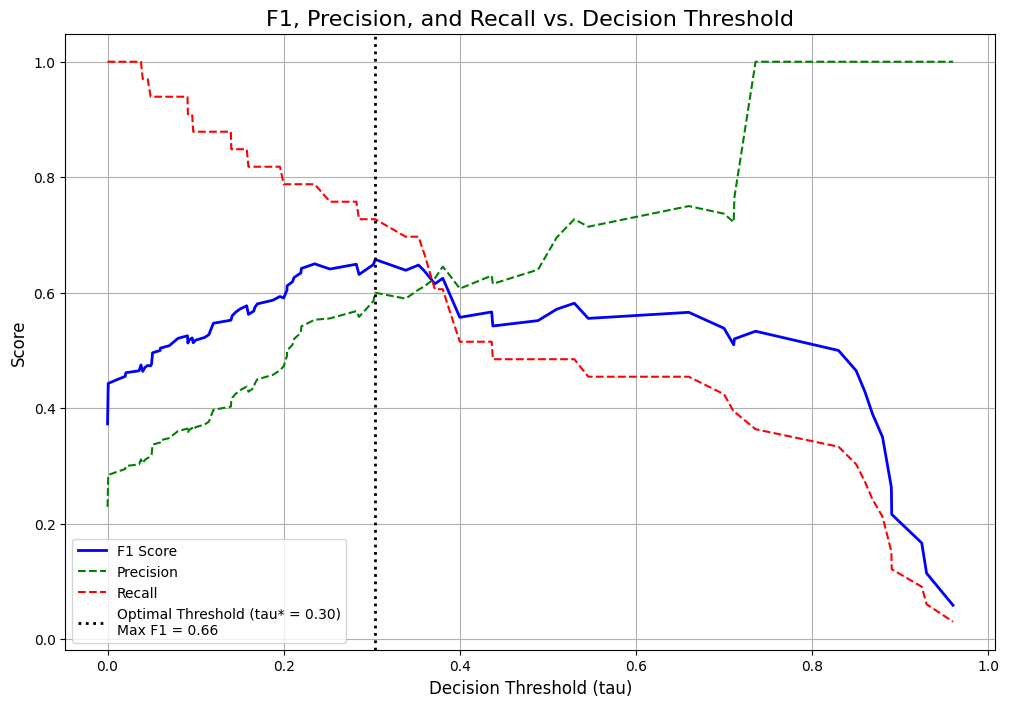

2025-11-09 04:29:19,376 - INFO - 
 meta-model hyperparameter analysis
2025-11-09 04:29:19,379 - INFO - 
Running meta-model analysis for RandomForest
/tmp/ipykernel_663361/3353455864.py:650: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna('None')
/tmp/ipykernel_663361/3353455864.py:652: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(0)
/tmp/ipykernel_663361/3353455864.py:655: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

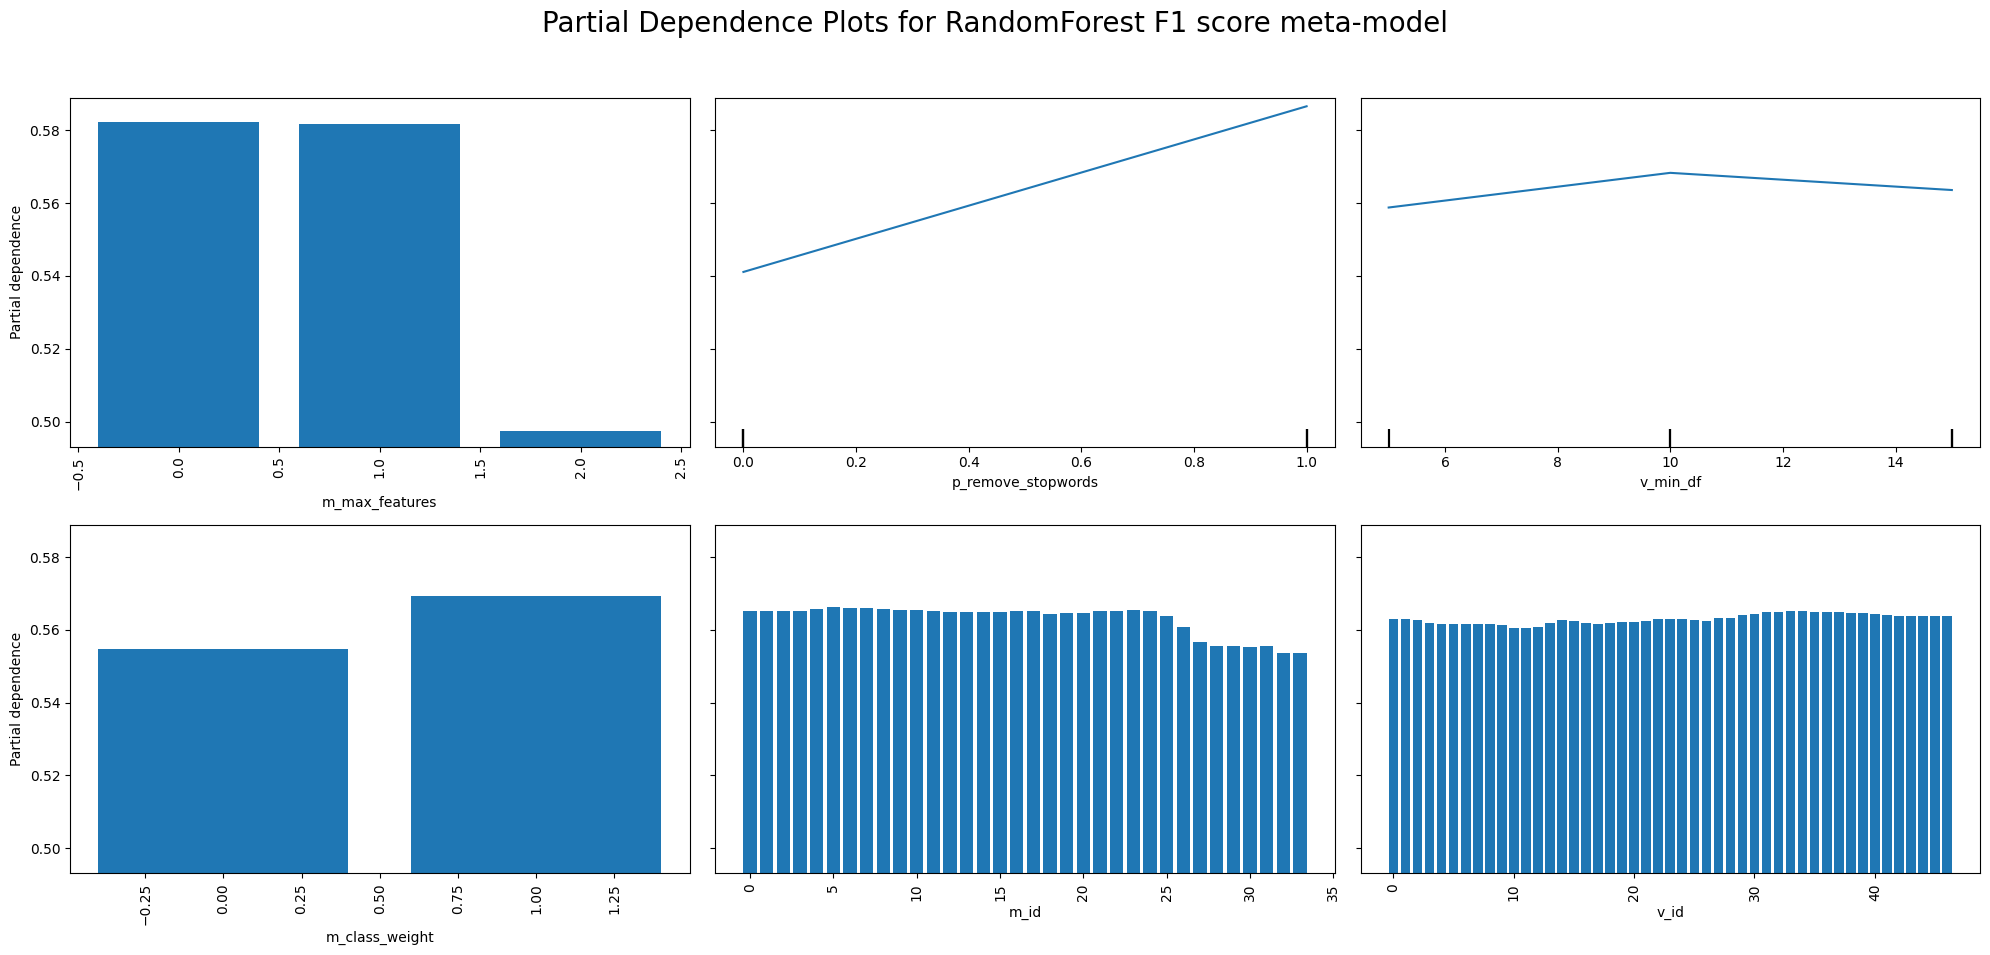

2025-11-09 04:29:19,794 - INFO - 
Running meta-model analysis for SVM
/tmp/ipykernel_663361/3353455864.py:650: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna('None')
/tmp/ipykernel_663361/3353455864.py:652: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(0)
/tmp/ipykernel_663361/3353455864.py:655: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

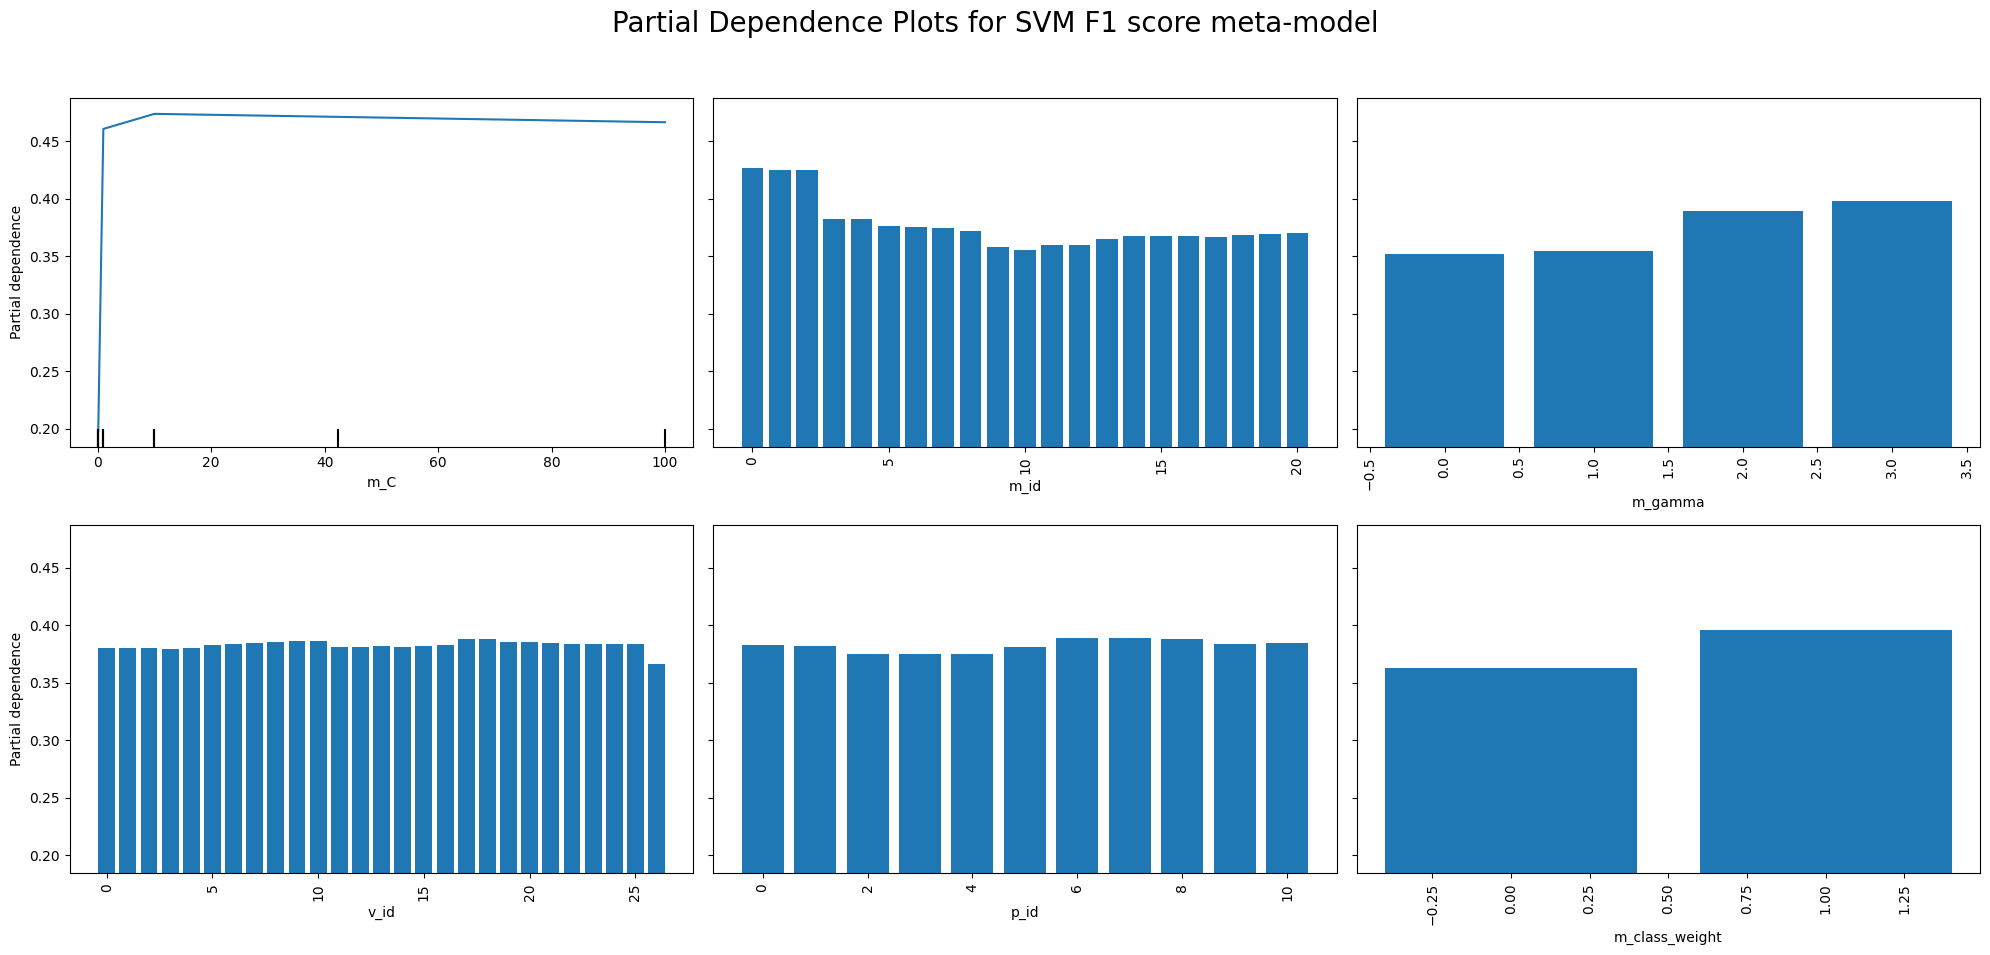

In [8]:

    # load the results of the search grid
    results_df = load_csv_to_dataframe(BASE_PATH / "grid_search_results.csv")

    # drop failed experiments
    results_df.dropna(subset=["f1_mean"], inplace=True)

    # get the best run
    best_run = results_df.sort_values(by="f1_mean", ascending=False).iloc[0]

    logging.info(f"\nBest model found")
    logging.info(f"experiment ID: {best_run['exp_id']}")
    logging.info(f"F1 Mean (at tau = 0.5): {best_run['f1_mean']:.4f}")

    # re-specify best model
    logging.info("\nre-specifying best model")
    model_type = "SVM" if "-SVM" in best_run["exp_id"] else "RF"
    p_params, v_params, m_params = parse_best_params(best_run, model_type)
    # check parameters
    required_keys = [
            'combine_strategy',
            'to_lower',
            'remove_punct',
            'remove_stopwords',
            'normalization_strategy'
            ]
    missing_keys = [key for key in required_keys if key not in p_params]
    if missing_keys:
        logging.error(f"failed, missing keys: {missing_keys}")
    X_corpus_preprocessed = create_preprocessed_corpus(validation_corpus_df_clean, **p_params)
    pipeline = rebuild_best_model(v_params, m_params, model_type)
    logging.info(f"rebuilt best model pipeline, see specs: {pipeline}")

    # threshold tau optimization for f1 score
    logging.info(f"\n threshold analysis")
    analyze_threshold(pipeline, X_corpus_preprocessed, validation_y_labels_clean)

    # meta model
    logging.info(f"\n meta-model hyperparameter analysis")
    analyze_meta_model(results_df)